<a href="https://colab.research.google.com/github/hgriff8173/Bank-Marketing-Analysis/blob/main/Bank_Marketing_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This project analyzes a bank's marketing campaign to identify patterns that could imrpove future campaign's effectiveness.

Imprting dataset to Google Colab for analysis.

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving bank-additional-full[1].csv to bank-additional-full[1].csv


Importing pandas, the library we use to work with data in Python. We then load the uploaded CSV file and preview the first five rows to confirm proper uploading.

In [ ]:
import pandas as pd

df = pd.read_csv(list(uploaded.keys())[0])
df.head()


,"age;""job"";""marital"";""education"";""default"";""housing"";""loan"";""contact"";""month"";""day_of_week"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""emp.var.rate"";""cons.price.idx"";""cons.conf.idx"";""euribor3m"";""nr.employed"";""y"""
0,"56;""housemaid"";""married"";""basic.4y"";""no"";""no"";..."
1,"57;""services"";""married"";""high.school"";""unknown..."
2,"37;""services"";""married"";""high.school"";""no"";""ye..."
3,"40;""admin."";""married"";""basic.6y"";""no"";""no"";""no..."
4,"56;""services"";""married"";""high.school"";""no"";""no..."


Upon first loading the data we encountered a KeyError on the 'y' column. Inspecting the column names revealed the file uses semicolons as separators instead of commas. We fixed this by adding sep=';' to the read_csv function, which correctly separated all 21 columns.

In [ ]:
(df['y'] == 'yes').mean()


KeyError: 'y'

In [ ]:
df.columns


Index(['age;"job";"marital";"education";"default";"housing";"loan";"contact";"month";"day_of_week";"duration";"campaign";"pdays";"previous";"poutcome";"emp.var.rate";"cons.price.idx";"cons.conf.idx";"euribor3m";"nr.employed";"y"'], dtype='object')

Here we ran our csv file check again and found that it had, indeed, been uploaded correctly.

In [ ]:
import pandas as pd

df = pd.read_csv(list(uploaded.keys())[0], sep=';')
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


After reloading the data correctly, we then verified that all 21 columns were now properly separated and confirmed our target of 'y' was accessible.

In [ ]:
df.columns


Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

Then we got our onversion rate.

In [ ]:
(df['y'] == 'yes').mean()


np.float64(0.11265417111780131)

Since the conversion rate was a long, ugly number,we converted it into somethnig cleaner and more workable.


In [ ]:
round((df['y'] == 'yes').mean() * 100, 2)


np.float64(11.27)

Next, we sorted conversion rates by job type to assess which jobs converted the most. This helps the bank identify which customer segments to prioritize in future campaigns.

In [ ]:
df.groupby('job')['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)


,y
job,
student,0.314286
retired,0.252326
unemployed,0.142012
admin.,0.129726
management,0.112175
unknown,0.112121
technician,0.108260
self-employed,0.104856
housemaid,0.100000


Since we now had our conversion rates per job, we needed to see how many actual people that translated into, so we got the value counts for each job. This showed that while students had the highest conversion rates, admin and blue-collar workers made the largest portions of this dataset.

In [ ]:
df['job'].value_counts()


,count
job,
admin.,10422
blue-collar,9254
technician,6743
services,3969
management,2924
retired,1720
entrepreneur,1456
self-employed,1421
housemaid,1060


In [ ]:
df['job'].value_counts(normalize=True) * 100


,proportion
job,
admin.,25.303486
blue-collar,22.467709
technician,16.371273
services,9.636302
management,7.099155
retired,4.175974
entrepreneur,3.535010
self-employed,3.450034
housemaid,2.573565


In [ ]:
df[df['y'] == 'yes']['job'].value_counts()


,count
job,
admin.,1352
technician,730
blue-collar,638
retired,434
management,328
services,323
student,275
self-employed,149
unemployed,144


In [ ]:
df['job'].value_counts()


,count
job,
admin.,10422
blue-collar,9254
technician,6743
services,3969
management,2924
retired,1720
entrepreneur,1456
self-employed,1421
housemaid,1060


After getting the value counts, we went ahead and got the proportion of our total yes's per job type to see who made up the actual majority of our converts. This confirmed that despite students having the highest conversion rate, admin workers generated the most total subscriptions due to their much larger share of the dataset at 25% of all contacts.

In [ ]:
df.groupby('month')['y'].apply(lambda x: (x == yes).mean()).sort_values(ascending=False)


NameError: name 'df' is not defined

Next, we attempted to group conversion rates by month, however, we encountered another error.

In [ ]:
df.groupby('month')['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)

NameError: name 'df' is not defined

Our session had reset so we needed to reupload our files.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving bank-additional-full[1].csv to bank-additional-full[1].csv


In [ ]:
import pandas as pd
df = pd.read_csv(list(uploaded.keys())[0], sep=';')

Then we were ready to analyze which months garnered the most conversion rates in order to gain insights about when our marketing teams should focus their calls. Based on our results, March has the highest conversion rate at 50%, followed closely by December, September, and October. April comes in next but at roughly half the conversion rate of our top four months. This may indicate that conversion rates peak before major financial milestones — March before tax season, December before year's end, October before the close of the business year, and September as the new school year begins. We recommend the bank focus campaign efforts heavily in these four months and reduce activity in May which shows the lowest conversion rate at only 6.4%.

In [ ]:
df.groupby('month')['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)

,y
month,
mar,0.505495
dec,0.489011
sep,0.449123
oct,0.438719
apr,0.204787
aug,0.106021
jun,0.105115
nov,0.101439
jul,0.090466


Prior campaign outcome (poutcome) shows a striking relationship with subscription rates. Clients previously engaged successfully are over 7x more likely to subscribe than new contacts, highlighting the value of relationship history in predicting the customer behavior.

In [ ]:
df.groupby('poutcome')['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)

,y
poutcome,
success,0.651129
failure,0.142286
nonexistent,0.088322


We can see that customers contacted by cell phones as opposed to landlines are more than twice as likely to convert, so we would suggest calling people by cellphone.

In [ ]:
df.groupby('contact')['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)

,y
contact,
cellular,0.147376
telephone,0.052313


University degree holders showed the highest subscription rate among education groups with sufficient sample size (13.7%), while basic education levels correlated with lower conversion, suggesting education level may weakly influence campaign receptiveness.

In [ ]:
df['education'].value_counts()

,count
education,
university.degree,12168
high.school,9515
basic.9y,6045
professional.course,5243
basic.4y,4176
basic.6y,2292
unknown,1731
illiterate,18


In [ ]:
df.groupby('education')['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)

,y
education,
illiterate,0.222222
unknown,0.145003
university.degree,0.137245
professional.course,0.113485
high.school,0.108355
basic.4y,0.102490
basic.6y,0.082024
basic.9y,0.078246


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Conversion rates vary dramatically by month, with March and December performing ~5x better than summer months like May and August. This suggests campaign timing is a critical factor — the bank may benefit from concentrating outreach efforts in Q4 and early Q1

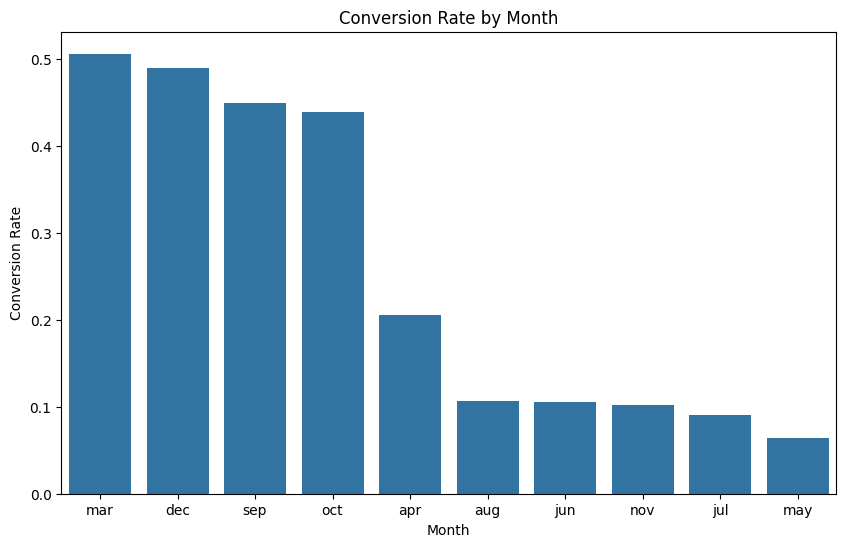

In [ ]:
month_data = df.groupby('month')['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=month_data.index, y=month_data.values)
plt.title('Conversion Rate by Month')
plt.ylabel('Conversion Rate')
plt.xlabel('Month')
plt.show()

Despite being underrepresented in the dataset, students and retired clients convert at significantly higher rates (31% and 25% respectively), nearly 4x that of blue-collar workers (7%). This suggests these segments may be high-value targets despite their smaller population.

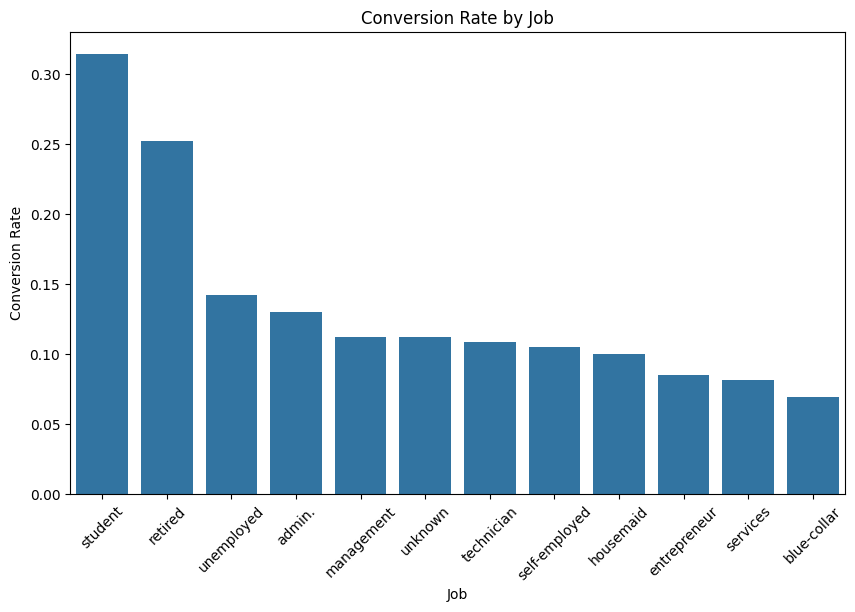

In [ ]:
job_data = df.groupby('job')['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=job_data.index, y=job_data.values)
plt.title('Conversion Rate by Job')
plt.ylabel('Conversion Rate')
plt.xlabel('Job')
plt.xticks(rotation=45)
plt.show()

The single strongest predictor of conversion was prior campaign outcome. Clients who had previously subscribed converted at 65% when re-contacted, compared to just 9% for new contacts. This suggests that re-engaging existing customers should be a top priority for campaign targeting, as they are 7x more likely to convert than cold leads

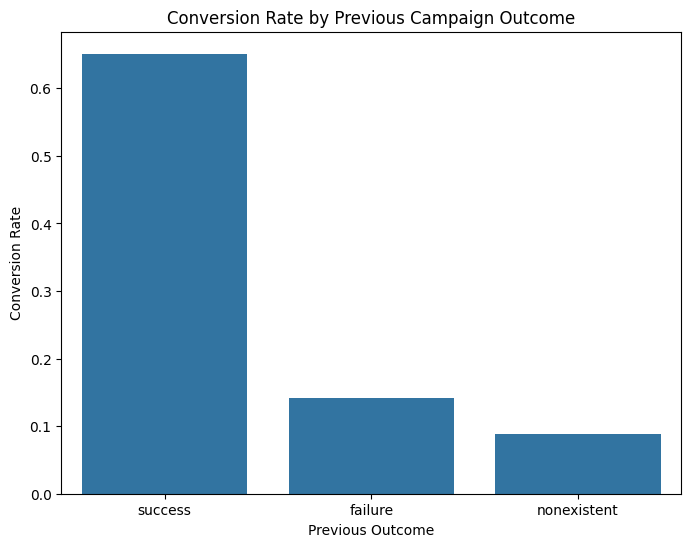

In [ ]:
poutcome_data = df.groupby('poutcome')['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=poutcome_data.index, y=poutcome_data.values)
plt.title('Conversion Rate by Previous Campaign Outcome')
plt.ylabel('Conversion Rate')
plt.xlabel('Previous Outcome')
plt.show()